In [100]:
import pandas as pd

batch_download_df = pd.read_csv("data/costs/cloud_run_jobs_with_estimated_cost_wildfires-pipeline-batch-download.csv")
batch_inference_df = pd.read_csv("data/costs/cloud_run_jobs_with_estimated_cost_wildfires-pipeline-inference.csv")
batch_inference_multiband_df = pd.read_csv("data/costs/cloud_run_jobs_with_estimated_cost_wildfires-pipeline-inference-multiband.csv")

metrics_df = pd.read_csv("data/costs/cloud_run_jobs_with_estimated_cost_wildfires-pipeline-metrics.csv")

firms_df = pd.read_csv("data/costs/cloud_run_jobs_with_estimated_cost_wildfires-pipeline-firms-test-1.csv")

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_duration(df, figsize=(10, 6), title=None):

    fig, ax1 = plt.subplots(figsize=figsize)

    sns.histplot(df['duration_seconds'], bins=10, kde=True, stat="count",
                 color='tab:blue', edgecolor='black', ax=ax1)

    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Cantidad')
    ax1.set_title('Tiempo de ejecución')

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

In [122]:
import pandas as pd

def get_costs_statistics(df, cutoff_date_str=None, cutoff_date_end=None, plot=True, print_run_dates=False):

    # Ensure datetime conversion once
    df['start_time'] = pd.to_datetime(df['start_time'], utc=True)

    # Apply start cutoff
    if cutoff_date_str is not None:
        cutoff_start = pd.Timestamp(cutoff_date_str, tz='UTC')
        df = df[df['start_time'] >= cutoff_start]

    # Apply end cutoff
    if cutoff_date_end is not None:
        cutoff_end = pd.Timestamp(cutoff_date_end, tz='UTC')
        df = df[df['start_time'] <= cutoff_end]

    # Stats
    max_run_time = df['duration_seconds'].max()
    min_run_time = df['duration_seconds'].min()
    avg_run_time = df['duration_seconds'].mean()

    max_cost = df['estimated_cost_usd'].max()
    min_cost = df['estimated_cost_usd'].min()
    avg_cost = df['estimated_cost_usd'].mean()

    if print_run_dates:
        for _, row in df.iterrows():
            print(row['start_time'], row['execution_id'])

    runs_count = df.shape[0]

    print(f"Analyzing {runs_count} runs\n")

    print(f"Max estimated cost: ${max_cost:.5f}")
    print(f"Min estimated cost: ${min_cost:.5f}")
    print(f"Average estimated cost: ${avg_cost:.5f}\n")

    print(f"Max run time: {max_run_time:.2f} seconds")
    print(f"Min run time: {min_run_time:.2f} seconds")
    print(f"Average run time: {avg_run_time:.2f} seconds")

    if plot:
        plot_duration(df)

Pipeline metrics

Analyzing 21 runs

Max estimated cost: $0.00687
Min estimated cost: $0.00159
Average estimated cost: $0.00314

Max run time: 361.63 seconds
Min run time: 83.49 seconds
Average run time: 165.14 seconds


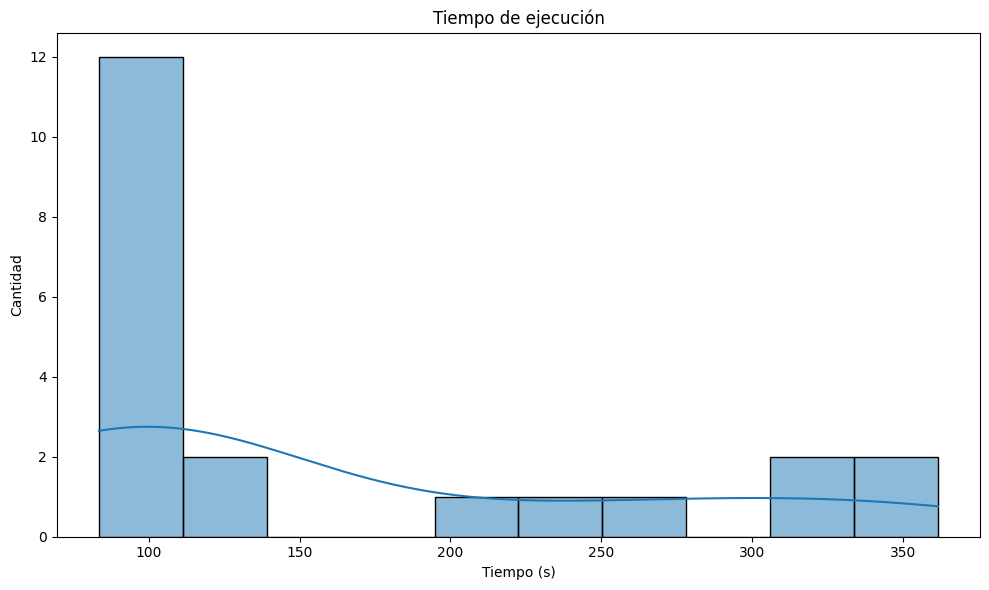

In [123]:
# Metrics 

print("Pipeline metrics\n")

get_costs_statistics(metrics_df, '2026-03-15')

Pipeline FIRMS

Analyzing 17 runs

Max estimated cost: $0.07494
Min estimated cost: $0.06268
Average estimated cost: $0.07053

Max run time: 986.09 seconds
Min run time: 824.76 seconds
Average run time: 928.04 seconds


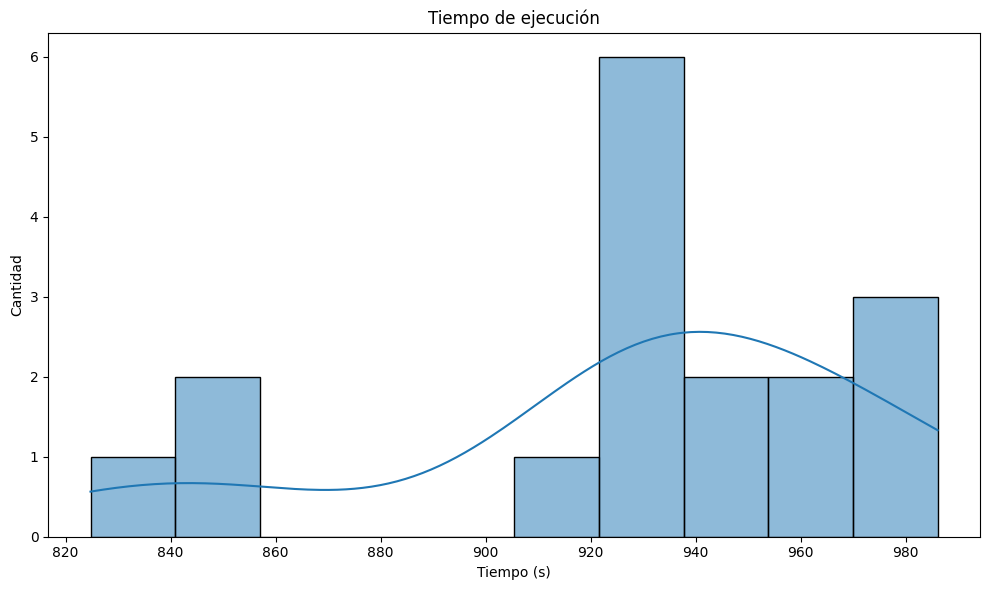

In [124]:
print("Pipeline FIRMS\n")
get_costs_statistics(firms_df, "2026-03-15")

In [125]:
print("Escaneo satelital - Descarga \n")

get_costs_statistics(batch_download_df, cutoff_date_str="2026-03-20", cutoff_date_end="2026-03-22", plot=False)

Escaneo satelital - Descarga 

Analyzing 6 runs

Max estimated cost: $0.09284
Min estimated cost: $0.08096
Average estimated cost: $0.08697

Max run time: 4886.53 seconds
Min run time: 4260.85 seconds
Average run time: 4577.19 seconds


In [126]:
print("Escaneo satelital - Inferencia RGB \n")

get_costs_statistics(batch_inference_df, cutoff_date_str="2026-03-20", cutoff_date_end="2026-03-23", plot=False)

Escaneo satelital - Inferencia RGB 

Analyzing 6 runs

Max estimated cost: $0.29334
Min estimated cost: $0.22452
Average estimated cost: $0.26544

Max run time: 808.77 seconds
Min run time: 619.02 seconds
Average run time: 731.84 seconds


In [130]:
print("Escaneo satelital - Inferencia Multibanda \n")

get_costs_statistics(batch_inference_multiband_df, cutoff_date_str="2026-03-20", cutoff_date_end="2026-03-23", plot=False, print_run_dates=True)

Escaneo satelital - Inferencia Multibanda 

2026-03-22 01:07:46.874678+00:00 wildfires-pipeline-inference-multiband-7fkhm
2026-03-22 01:04:56.873453+00:00 wildfires-pipeline-inference-multiband-tx6l2
2026-03-21 23:40:46.782233+00:00 wildfires-pipeline-inference-multiband-jdf5v
2026-03-21 23:35:38.775090+00:00 wildfires-pipeline-inference-multiband-jjh86
2026-03-21 23:31:00.774669+00:00 wildfires-pipeline-inference-multiband-lfx8t
2026-03-21 18:20:50.420878+00:00 wildfires-pipeline-inference-multiband-kgcz5
2026-03-20 04:56:26.007217+00:00 wildfires-pipeline-inference-multiband-xk9jj
Analyzing 7 runs

Max estimated cost: $0.01851
Min estimated cost: $0.00364
Average estimated cost: $0.01151

Max run time: 462.81 seconds
Min run time: 90.95 seconds
Average run time: 287.69 seconds
